In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
train_df = pd.read_csv('train.csv', low_memory=False)
store_df = pd.read_csv('store.csv')

print(f"Training Data Shape: {train_df.shape}")
print(f"Store Info Shape: {store_df.shape}")

display(train_df.head(3))

display(store_df.head(3))

Training Data Shape: (1017209, 9)
Store Info Shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


--- Missing Values in Sales Data ---
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

--- Missing Values in Store Data ---
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


C:\Users\Rohan Taigade\AppData\Local\Temp\ipykernel_2740\138414835.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promo', y='Sales', data=train_df, palette='viridis')


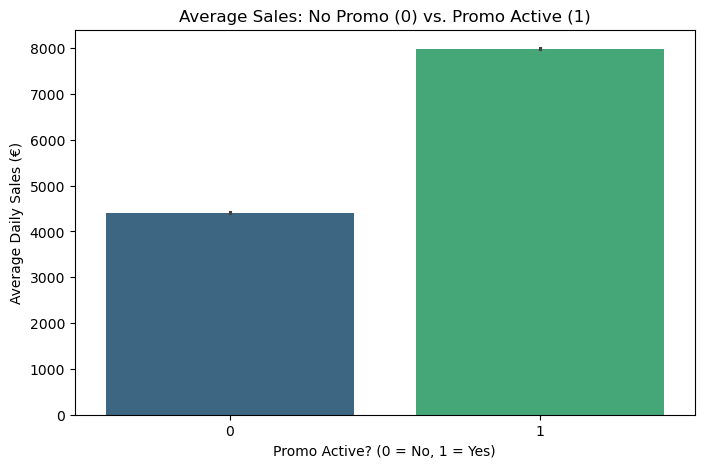

In [9]:
# 1. Check for missing values (Nulls)
print("--- Missing Values in Sales Data ---")
print(train_df.isnull().sum())

print("\n--- Missing Values in Store Data ---")
print(store_df.isnull().sum())

# 2. Let's make our FIRST PLOT: The Promo Effect!
plt.figure(figsize=(8, 5))
sns.barplot(x='Promo', y='Sales', data=train_df, palette='viridis')
plt.title("Average Sales: No Promo (0) vs. Promo Active (1)")
plt.xlabel("Promo Active? (0 = No, 1 = Yes)")
plt.ylabel("Average Daily Sales (€)")
plt.show()

In [10]:
# 1. Fill the 3 missing Competition Distances with the median distance
store_df['CompetitionDistance'] = store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].median())

# 2. Fill all the missing Promo2 and Competition Open dates with 0
store_df = store_df.fillna(0)

# 3. Check again to prove we fixed it!
print("--- Missing Values in Store Data AFTER Cleaning ---")
print(store_df.isnull().sum())

--- Missing Values in Store Data AFTER Cleaning ---
Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


New Merged Dataset Shape: (1017209, 18)


C:\Users\Rohan Taigade\AppData\Local\Temp\ipykernel_2740\2876040403.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='Sales', data=df, palette='magma')


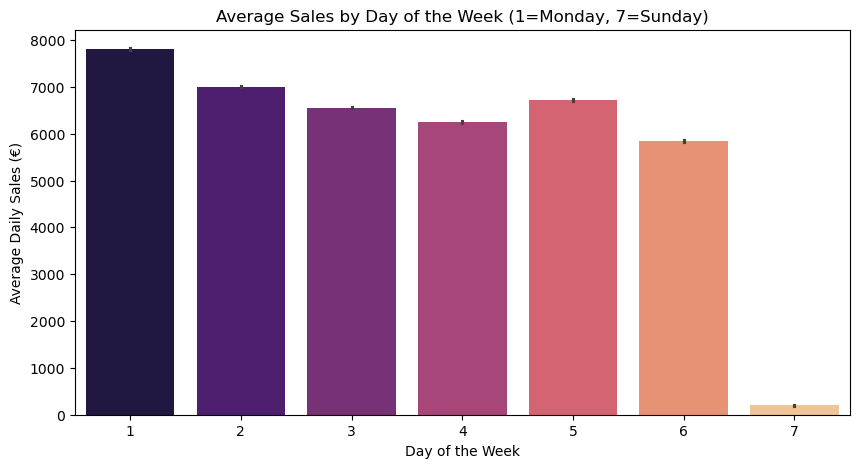

In [12]:
# 1. THE MERGE: Smash the two datasets together based on the 'Store' ID number
df = pd.merge(train_df, store_df, on='Store', how='left')
print(f"New Merged Dataset Shape: {df.shape}")

# 2. TIME TRAVEL: Convert the text 'Date' into a real Python Time object
df['Date'] = pd.to_datetime(df['Date'])

# 3. FEATURE ENGINEERING (Phase 1): Extract Month, Year, and Day
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# 4. PLOT: Let's see how human behavior changes throughout the week!
plt.figure(figsize=(10, 5))
sns.barplot(x='DayOfWeek', y='Sales', data=df, palette='magma')
plt.title("Average Sales by Day of the Week (1=Monday, 7=Sunday)")
plt.xlabel("Day of the Week")
plt.ylabel("Average Daily Sales (€)")
plt.show()

Open
1    844392
0    172817
Name: count, dtype: int64

Old shape (with closed days): (1017209, 21)
New shape (only open days): (844338, 21)


C:\Users\Rohan Taigade\AppData\Local\Temp\ipykernel_2740\973525390.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='Sales', data=df_open, palette='magma')


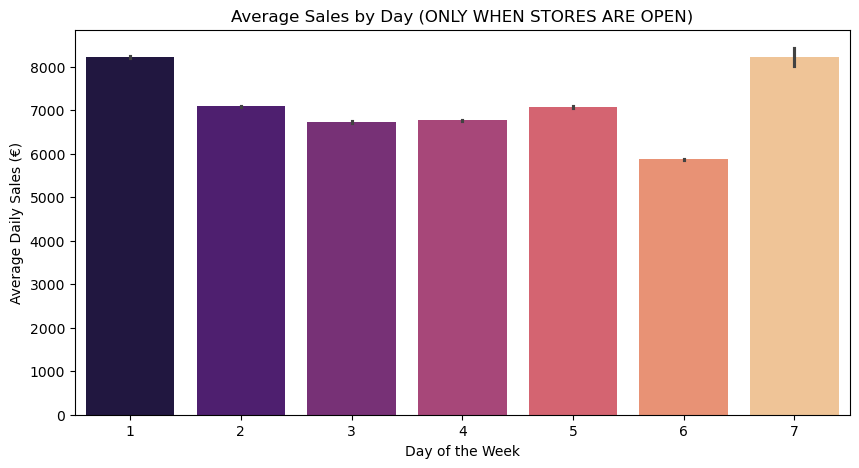

In [13]:
# 1. Count how many times stores were Closed (0) vs Open (1)
print(df['Open'].value_counts())

# 2. THE FILTER: Keep ONLY the rows where the store is actually OPEN and made more than 0 sales.
df_open = df[(df['Open'] == 1) & (df['Sales'] > 0)]

print(f"\nOld shape (with closed days): {df.shape}")
print(f"New shape (only open days): {df_open.shape}")

# 3. Let's look at the Sunday bar chart again, but ONLY for the stores legally allowed to open!
plt.figure(figsize=(10, 5))
sns.barplot(x='DayOfWeek', y='Sales', data=df_open, palette='magma')
plt.title("Average Sales by Day (ONLY WHEN STORES ARE OPEN)")
plt.xlabel("Day of the Week")
plt.ylabel("Average Daily Sales (€)")
plt.show()

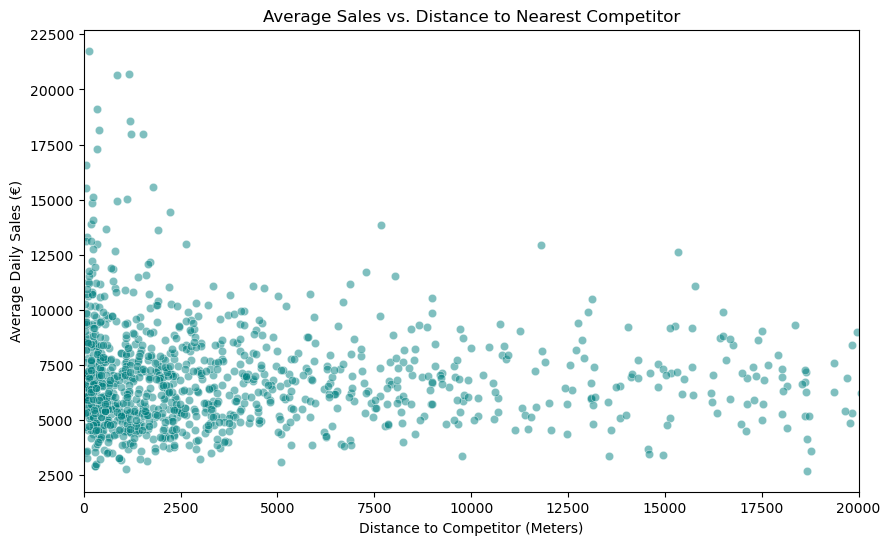

In [14]:
# 1. Calculate the average daily sales for each store
store_avg = df_open.groupby('Store').agg({
    'Sales': 'mean',
    'CompetitionDistance': 'first' # The distance is the same for the whole store
}).reset_index()

# 2. Make a Scatter Plot to see the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CompetitionDistance', y='Sales', data=store_avg, alpha=0.5, color='teal')
plt.title("Average Sales vs. Distance to Nearest Competitor")
plt.xlabel("Distance to Competitor (Meters)")
plt.ylabel("Average Daily Sales (€)")

# Limit the x-axis slightly because a few stores have competitors 70,000 meters away!
plt.xlim(0, 20000) 
plt.show()